In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


In [2]:
import seaborn as sns

# Load dataset
df = sns.load_dataset('titanic')

# Select relevant features
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].dropna()

# Encode categorical variable
df['sex'] = LabelEncoder().fit_transform(df['sex'])  # male=1, female=0

# Split features and target
X = df.drop('survived', axis=1)
y = df['survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
#Logistic Regression - Baseline, interpretable
#Random Forest - Robust, handles non-linearity
#AdaBoost-Sequential error correction

In [6]:
log_model = LogisticRegression(max_iter=1000)
#it models the probability of survival(1) as a logistic(sigmoid) function of input features
#it finds coefficients bi that separates survivors from non-survivors
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))


Logistic Regression
Accuracy: 0.772093023255814
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       126
           1       0.76      0.66      0.71        89

    accuracy                           0.77       215
   macro avg       0.77      0.76      0.76       215
weighted avg       0.77      0.77      0.77       215



In [7]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print(" Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# final prediction is made by majority of vote all trees

 Random Forest
Accuracy: 0.7906976744186046
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       126
           1       0.78      0.70      0.73        89

    accuracy                           0.79       215
   macro avg       0.79      0.78      0.78       215
weighted avg       0.79      0.79      0.79       215



In [8]:
ada_model = AdaBoostClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)

print(" AdaBoost")
print("Accuracy:", accuracy_score(y_test, ada_pred))
print(classification_report(y_test, ada_pred))

#final model is a wighted sum of all 50 trees


 AdaBoost
Accuracy: 0.7627906976744186
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       126
           1       0.72      0.71      0.71        89

    accuracy                           0.76       215
   macro avg       0.76      0.75      0.76       215
weighted avg       0.76      0.76      0.76       215



C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


In [9]:
#Extract Feature Importance

In [ ]:
#Logistic Regression – Coefficients

<Axes: title={'center': 'Logistic Regression Feature Importance'}>

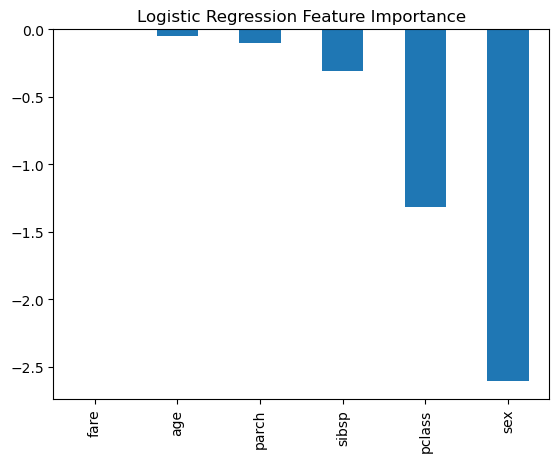

In [10]:
# Feature importance from logistic regression
log_importance = pd.Series(log_model.coef_[0], index=X.columns)
log_importance.sort_values(ascending=False).plot(kind='bar', title='Logistic Regression Feature Importance')

#Coefficients show direction and strength of influence.

#Positive → increases survival probability

#Negative → decreases survival probability


In [ ]:
#Random Forest – Gini Importance

#Measures how much each feature reduces impurity across all trees.

#More splits on a feature → higher importance

<Axes: title={'center': 'Random Forest Feature Importance'}>

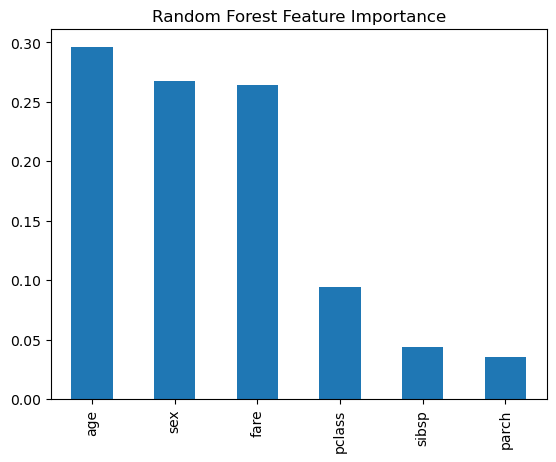

In [11]:
# Feature importance from random forest
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_importance.sort_values(ascending=False).plot(kind='bar', title='Random Forest Feature Importance')


In [ ]:
#AdaBoost – Weighted Importance
#Based on how often and how effectively each feature is used by weak learners.
#Reflects error-driven learning — features that help correct mistakes get more weight

<Axes: title={'center': 'AdaBoost Feature Importance'}>

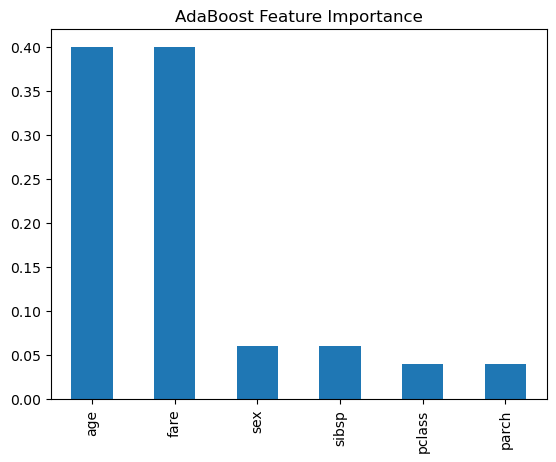

In [12]:
# Feature importance from AdaBoost
ada_importance = pd.Series(ada_model.feature_importances_, index=X.columns)
ada_importance.sort_values(ascending=False).plot(kind='bar', title='AdaBoost Feature Importance')


In [ ]:
#Logistic Regression gives directional insights — useful for interpretation.

#Random Forest and AdaBoost give relative importance — useful for feature selection.

#Comparing them helps you decide which features to keep, drop, or engineer further.